In [1]:
import pandas as pd

# Load a CSV file into a DataFrame (for easier manipulation)
adni_metadata = pd.read_csv('ADNI/ADNI1_Complete_1Yr_1.5T_5_07_2025.csv')
for i, p in enumerate(adni_metadata['Subject']):
    pass
print(i)
print(set(adni_metadata['Group']))

1341
{'CN', 'AD', 'MCI'}


In [2]:
adni_metadata['Subject'][:5]

0    941_S_1202
1    941_S_1202
2    941_S_1202
3    941_S_1194
4    941_S_1194
Name: Subject, dtype: object

In [3]:
adni_metadata

,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded
0,I63874,941_S_1202,CN,M,78,sc,MRI,MPR-R; GradWarp; B1 Correction; N3; Scaled,Processed,1/30/2007,NiFTI,3/13/2025
1,I75150,941_S_1202,CN,M,78,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,8/24/2007,NiFTI,3/13/2025
2,I105437,941_S_1202,CN,M,79,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,2/28/2008,NiFTI,3/13/2025
3,I63847,941_S_1194,CN,M,85,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,1/20/2007,NiFTI,3/13/2025
4,I103731,941_S_1194,CN,M,86,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,3/25/2008,NiFTI,3/13/2025
...,...,...,...,...,...,...,...,...,...,...,...,...
1337,I118671,002_S_0295,CN,M,85,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled_2,Processed,4/18/2006,NiFTI,3/13/2025
1338,I118692,002_S_0295,CN,M,85,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled_2,Processed,11/02/2006,NiFTI,3/13/2025
1339,I64025,002_S_0295,CN,M,86,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,5/25/2007,NiFTI,3/13/2025
1340,I40966,002_S_0295,CN,M,85,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,11/02/2006,NiFTI,3/13/2025


In [4]:
segments_df = pd.DataFrame(columns=['ID', 'Original Shape', 'Cropped Lower Index', 'Cropped Upper Index'])
display(segments_df)

,ID,Original Shape,Cropped Lower Index,Cropped Upper Index


In [ ]:
adni_metadata['Subject'][:3]

0       941_S_1202
1       941_S_1202
2       941_S_1202
3       941_S_1194
4       941_S_1194
           ...    
1337    002_S_0295
1338    002_S_0295
1339    002_S_0295
1340    002_S_0295
1341    002_S_0295
Name: Subject, Length: 1342, dtype: object

In [8]:
import ants
import antspynet
import os
import numpy as np
import csv

# imgs = []
# REPLACE_EXISTING = False
# idx = []
count = 0
data_file = "data/adni_segments/subblocks2/segments.csv"
with open("data/adni_segments/subblocks2/segments.csv", "a", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(["id_name", "seg_shape", "lowerind", "upperind"])
for i, p in enumerate(adni_metadata['Subject'][:3]):
    try:
        populated = False
        path = f'ADNI/{p}/{adni_metadata["Description"][i].replace(";","_").replace(" ","_")}'
        for root, dirs, files in os.walk(path):
            for file in files:
                if file.endswith(adni_metadata["Image Data ID"][i] + '.nii'):
                    img = ants.image_read(root + "/" + file)
                    # if img.shape[2] == 166:
                    #     idx.append(i)
                    img = antspynet.harvard_oxford_atlas_labeling(img)['probability_images']
                    for seg_no, seg in enumerate(img):
                        count += 1
                        id_name = f'{p}_{adni_metadata["Image Data ID"][i]}_seg_{seg_no}'
                        mask = seg >= 1E-1
                        cropped_img = ants.crop_image(seg, mask)

                        t1 = np.array(np.where(mask.numpy()))
                        lowerind = t1.min(axis=1)
                        upperind = t1.max(axis=1) + 1  # +1 because slicing is exclusive
                        
                        if (seg_no > 0):
                            # segments_df.loc[len(segments_df)] = [id_name,seg.shape,lowerind,upperind]
                            ants.image_write(cropped_img, f'data/adni_segments/subblocks2/{id_name}.nii')
                            with open("data/adni_segments/subblocks2/segments.csv", "a", newline="") as file:
                                writer = csv.writer(file)
                                writer.writerow([id_name,seg.shape,lowerind,upperind])

                        
                        populated = True
                        # ants.resample_image(seg, resample_params=(64,64,64), use_voxels=True, interp_type=1)
                    # mask = masking.compute_brain_mask(img)
                    # brain_img = masking.apply_mask(img, mask)
                    # imgs.append(segments)
        if not populated:
            print(f"Not written: {p} ({adni_metadata["Description"][i]} {adni_metadata["Image Data ID"][i]})")
    except:
        print(f"Error: {p}")

In [1]:
segments_df

NameError: name 'segments_df' is not defined

In [25]:
[id_name,seg.shape,lowerind,upperind]

['941_S_1202_I63874_seg_1',
 (192, 192, 160),
 array([69, 72, 77], dtype=int64),
 array([145, 141, 117], dtype=int64)]

In [30]:
display(segments_df)

,ID,Original Shape,Cropped Lower Index,Cropped Upper Index
0,941_S_1202_I63874_seg_1,"(192, 192, 160)","[69, 72, 77]","[145, 140, 117]"
1,941_S_1202_I63874_seg_2,"(192, 192, 160)","[71, 74, 47]","[145, 148, 83]"
2,941_S_1202_I63874_seg_3,"(192, 192, 160)","[89, 88, 73]","[107, 120, 91]"
3,941_S_1202_I63874_seg_4,"(192, 192, 160)","[92, 87, 75]","[105, 113, 84]"
4,941_S_1202_I63874_seg_5,"(192, 192, 160)","[89, 94, 48]","[155, 134, 115]"
...,...,...,...,...
59,941_S_1202_I63874_seg_28,"(192, 192, 160)","[96, 97, 57]","[114, 115, 82]"
60,941_S_1202_I63874_seg_29,"(192, 192, 160)","[114, 98, 82]","[159, 146, 130]"
61,941_S_1202_I63874_seg_30,"(192, 192, 160)","[115, 103, 38]","[162, 148, 86]"
62,941_S_1202_I63874_seg_31,"(192, 192, 160)","[117, 97, 82]","[154, 135, 120]"


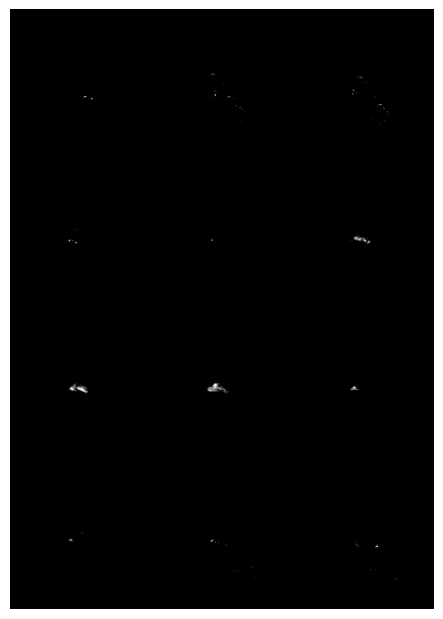

(192, 192, 160)
(186, 175, 160)


In [81]:
import numpy as np
id = 4
# Get the non-zero voxel indices
nonzero_indices = np.array(img[id].nonzero())

# Compute bounding box (min and max indices along each axis)
lowerind = nonzero_indices.min(axis=1)
upperind = nonzero_indices.max(axis=1) + 1  # +1 because slicing is exclusive

test = ants.crop_indices(img[id], lowerind.tolist(), upperind.tolist())
ants.plot(test)
print(img[id].shape)
print(test.shape)

In [82]:
mask = img[id] >= 1E-1
cropped_img = ants.crop_image(img[id], mask)

In [ ]:
t1 = np.array(np.where(mask.numpy()))
lowerind = t1.min(axis=1)
upperind = t1.max(axis=1) + 1  # +1 because slicing is exclusive
print(lowerind, upperind, upperind - lowerind)

[92 86 75] [105 113  84] [98.5 99.5 79.5] [13 27  9]


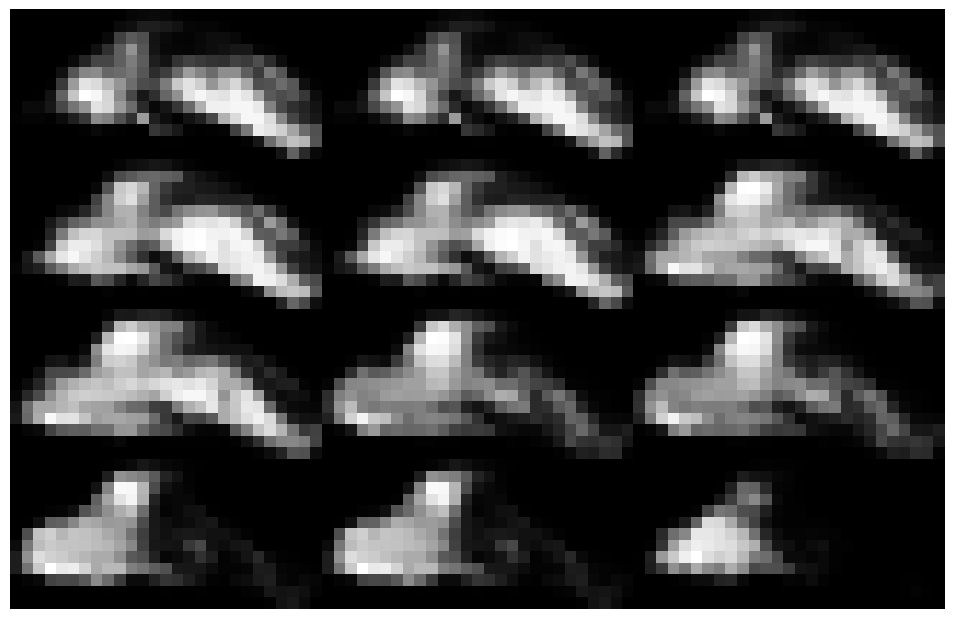

(192, 192, 160)
(13, 27, 9)


In [84]:
ants.plot(cropped_img)
print(img[id].shape)
print(cropped_img.shape)

In [37]:
img[id].nonzero()[2].shape

(2329897,)

In [5]:
Y = adni_metadata["Group"][:267]
X = adni_metadata["Subject"][:267] + "_" + adni_metadata["Image Data ID"][:267]

In [6]:
import ants
def get_segment(X_description, segment, size=None):
    img = ants.image_read(f'data/adni_segments/segments_1plus2/{X_description}_seg_{segment}.nii')
    if size is not None:
        img = ants.resample_image(img, resample_params=size, use_voxels=True, interp_type=1)
    return (img.numpy(), segment, size)

In [7]:
get_segment(X[0], 0, (64,64,64))[0].shape

(64, 64, 64)

In [8]:
adni_metadata

,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded
0,I63874,941_S_1202,CN,M,78,sc,MRI,MPR-R; GradWarp; B1 Correction; N3; Scaled,Processed,1/30/2007,NiFTI,3/13/2025
1,I75150,941_S_1202,CN,M,78,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,8/24/2007,NiFTI,3/13/2025
2,I105437,941_S_1202,CN,M,79,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,2/28/2008,NiFTI,3/13/2025
3,I63847,941_S_1194,CN,M,85,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,1/20/2007,NiFTI,3/13/2025
4,I103731,941_S_1194,CN,M,86,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,3/25/2008,NiFTI,3/13/2025
...,...,...,...,...,...,...,...,...,...,...,...,...
1337,I118671,002_S_0295,CN,M,85,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled_2,Processed,4/18/2006,NiFTI,3/13/2025
1338,I118692,002_S_0295,CN,M,85,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled_2,Processed,11/02/2006,NiFTI,3/13/2025
1339,I64025,002_S_0295,CN,M,86,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,5/25/2007,NiFTI,3/13/2025
1340,I40966,002_S_0295,CN,M,85,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,11/02/2006,NiFTI,3/13/2025


In [115]:
len(idx)

558

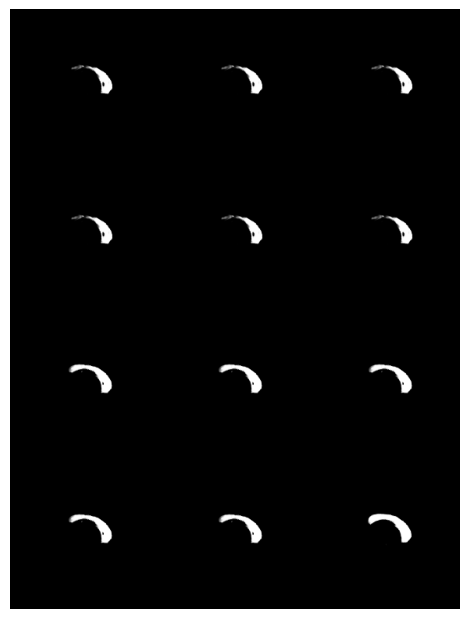

In [89]:
ants.plot(img[1])

In [91]:
test = ants.resample_image(img[1], resample_params=(64,64,64), use_voxels=True, interp_type=1)
ants.image_write(test, 'data/adni_segments/test.nii')

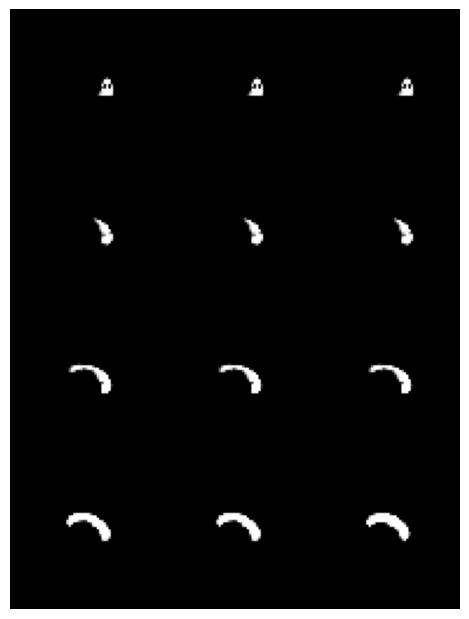

{0.0,
 5.48e-43,
 3e-45,
 1.2997719e-38,
 1e-45,
 1.5e-44,
 3.6191e-41,
 4.7034566e-38,
 4e-45,
 2.8e-43,
 1.28e-43,
 1.65e-43,
 9.928313e-39,
 5.616572e-38,
 3.204754e-39,
 2.929e-42,
 1.0702101e-18,
 1.1385215e-18,
 2.5151043e-36,
 1.6887174e-18,
 7.830558e-18,
 1.2264361e-30,
 7.038609e-18,
 1.4778405e-18,
 4.5312233e-36,
 3.9086468e-36,
 1.1579235e-17,
 1.0236686e-36,
 5.304155e-36,
 8.510797e-37,
 1.2840823e-17,
 1.8e-44,
 1.4274648e-20,
 5.7617e-41,
 3.6878394e-21,
 2.6096e-40,
 1.6071e-41,
 7.68e-43,
 6.9e-43,
 1.46e-43,
 1.4541053e-17,
 1.6701937e-36,
 3.7623198e-18,
 3.5072284e-18,
 1.9110206e-17,
 3.6907595e-18,
 4.2420146e-18,
 4.1679435e-18,
 4.15385e-18,
 9.200317e-36,
 8.341265e-36,
 9.729963e-36,
 2.0925157e-17,
 1.9253266e-17,
 4.101286e-18,
 4.317428e-18,
 4.9424327e-18,
 1.0928628e-18,
 5.204835e-37,
 8.843481e-19,
 9.346408e-19,
 2.27805e-36,
 2.392541e-36,
 1.03019165e-35,
 1.2222468e-35,
 8.905171e-19,
 2.5885852e-36,
 2.9454654e-17,
 2.866753e-17,
 1.145911e-35,
 

In [97]:
ants.plot(test)
set(test.numpy().reshape(-1))

In [37]:
file.endswith(adni_metadata["Image Data ID"][i] + '.nii')

False

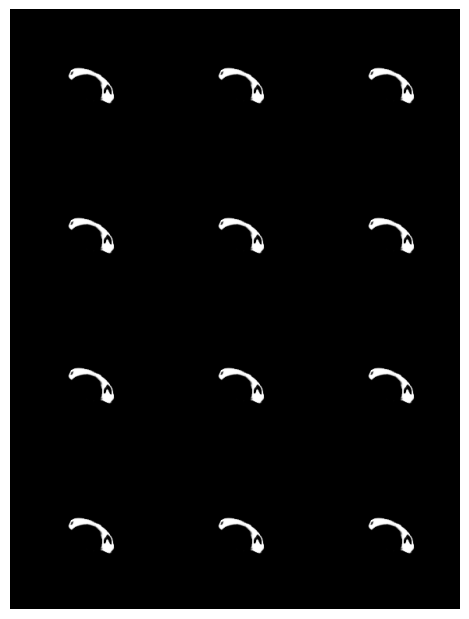

In [24]:
test = ants.image_read(f'data/adni_segments/{p}_seg_1.nii')
ants.plot(test)

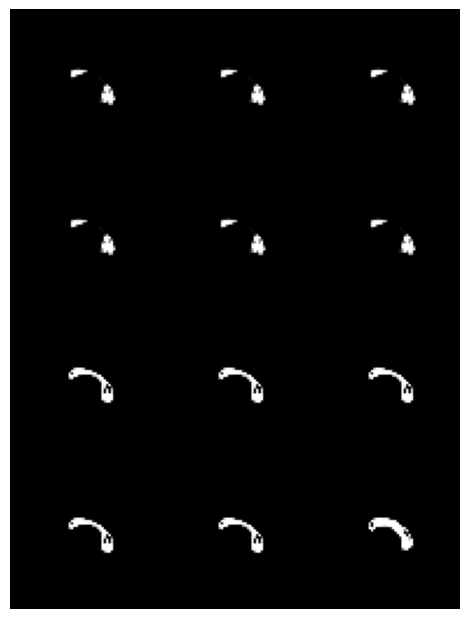

In [97]:
ants.plot(imgs[1][1])

In [53]:
def extract_segment(all_segments, seg):
    if type(seg) == list:
        out_segment = all_segments[seg[0]]
        for i in range(1,len(seg)):
            out_segment += all_segments[seg[i]]
    else:
        out_segment = all_segments[seg]
    return (out_segment.numpy(), seg)

In [80]:
extract_segment(imgs[0], 1)

array([[[3.4135631e-41, 1.3820114e-35, 1.1104004e-29, ...,
         7.0213451e-27, 2.1747737e-25, 2.1610097e-24],
        [8.1005981e-40, 1.1329295e-34, 1.9863006e-28, ...,
         1.0065108e-34, 5.7359470e-33, 2.0105218e-31],
        [7.5116279e-38, 4.7428236e-33, 1.8453384e-27, ...,
         2.3374335e-38, 5.2152125e-41, 6.1317318e-40],
        ...,
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         4.7435322e-26, 1.3839998e-30, 1.1758522e-31],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         1.7468934e-18, 5.5458009e-21, 8.9303874e-24],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ...,
         1.4309810e-16, 3.2924852e-17, 2.4184577e-17]],

       [[7.5584638e-41, 5.1222643e-35, 2.9281355e-28, ...,
         2.9092824e-37, 6.5434692e-36, 1.8822896e-34],
        [1.0439866e-37, 5.1492542e-32, 5.6154213e-26, ...,
         1.1526023e-33, 4.1574317e-36, 2.0994694e-34],
        [1.7759782e-33, 1.7343859e-28, 1.5821756e-24, ...,
         1.796

In [117]:
adni_metadata

,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded
0,I63874,941_S_1202,CN,M,78,sc,MRI,MPR-R; GradWarp; B1 Correction; N3; Scaled,Processed,1/30/2007,NiFTI,3/13/2025
1,I75150,941_S_1202,CN,M,78,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,8/24/2007,NiFTI,3/13/2025
2,I105437,941_S_1202,CN,M,79,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,2/28/2008,NiFTI,3/13/2025
3,I63847,941_S_1194,CN,M,85,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,1/20/2007,NiFTI,3/13/2025
4,I103731,941_S_1194,CN,M,86,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,3/25/2008,NiFTI,3/13/2025
...,...,...,...,...,...,...,...,...,...,...,...,...
1337,I118671,002_S_0295,CN,M,85,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled_2,Processed,4/18/2006,NiFTI,3/13/2025
1338,I118692,002_S_0295,CN,M,85,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled_2,Processed,11/02/2006,NiFTI,3/13/2025
1339,I64025,002_S_0295,CN,M,86,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,5/25/2007,NiFTI,3/13/2025
1340,I40966,002_S_0295,CN,M,85,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,11/02/2006,NiFTI,3/13/2025


In [119]:
Y_multi = adni_metadata['Group'][idx]

In [66]:
imgs[1][1].shape

(55, 59, 35)

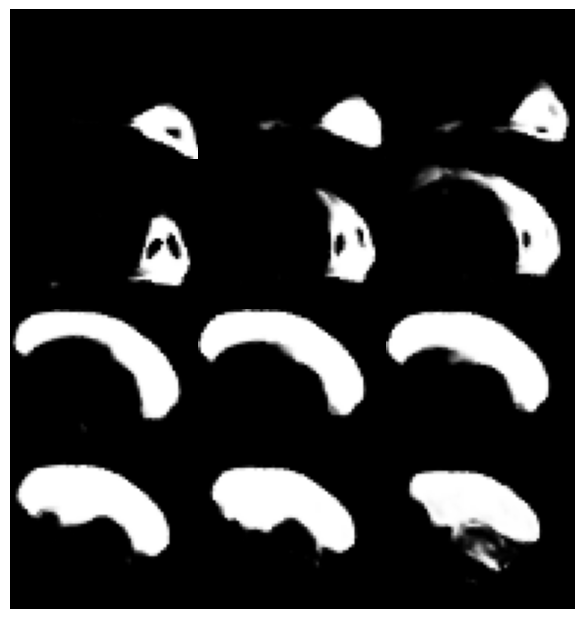

In [61]:
ants.plot(imgs[0][1])

In [48]:
import numpy as np
test = imgs[0]['probability_images'][1].numpy()
print(test.shape)
np.sum(imgs[0]['probability_images'][1].numpy() != 0)

(192, 192, 160)


433094

In [49]:
imgs[0]['probability_images'][1].crop_image().shape

(51, 64, 38)

In [ ]:
folds = {}
for j, y in enumerate([Y0, Y1]):
    folds[j] = []
    for i in range(5):
        p_list = [[24,24]]
        lam = [2**i for i in range(-2,0)]
        params = {
            'p': p_list,
            'lama': lam,
            'lamb': 0.5,
            'lamz': 0,
            'g': Logit(),
            # 'R': 1,
            'max_iter': 10,
            # 'K': K,
            'n_cores': 1
        }
        ensemble_model = EnsembleCSKPD()
        X_pick = [X[k] for k in train_k[i]]
        ensemble_model.fit(X_pick, y[train_k[i]], model_parameters=[
            {'L': convolution(extract_and_resize, {'slice': 'tra', 'instance': tra_max, 'size': (96,96)}, extract_and_resize)},
            {'L': convolution(extract_and_resize, {'slice': 'cor', 'instance': tra_max, 'size': (96,96)}, extract_and_resize)},
            {'L': convolution(extract_and_resize, {'slice': 'sag', 'instance': tra_max, 'size': (96,96)}, extract_and_resize)},
            ], common_parameters=params)
        folds[j].append(ensemble_model)

In [1]:
import pickle
with open('adni.pkl', 'rb') as f:
    X, Y = pickle.load(f).values()

In [69]:
len(X)

558

In [70]:
adni_metadata

,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded
0,I63874,941_S_1202,CN,M,78,sc,MRI,MPR-R; GradWarp; B1 Correction; N3; Scaled,Processed,1/30/2007,NiFTI,3/13/2025
1,I75150,941_S_1202,CN,M,78,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,8/24/2007,NiFTI,3/13/2025
2,I105437,941_S_1202,CN,M,79,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,2/28/2008,NiFTI,3/13/2025
3,I63847,941_S_1194,CN,M,85,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,1/20/2007,NiFTI,3/13/2025
4,I103731,941_S_1194,CN,M,86,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,3/25/2008,NiFTI,3/13/2025
...,...,...,...,...,...,...,...,...,...,...,...,...
1337,I118671,002_S_0295,CN,M,85,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled_2,Processed,4/18/2006,NiFTI,3/13/2025
1338,I118692,002_S_0295,CN,M,85,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled_2,Processed,11/02/2006,NiFTI,3/13/2025
1339,I64025,002_S_0295,CN,M,86,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,5/25/2007,NiFTI,3/13/2025
1340,I40966,002_S_0295,CN,M,85,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,11/02/2006,NiFTI,3/13/2025


In [67]:
descriptions = [a.split('; ') for a in adni_metadata['Description']]
for d in descriptions:
    if len(d) != 5:
        d.append(d[3])
        d[3] = d[2]
        d[2] = ''
descriptions = pd.DataFrame(descriptions)
descriptions.columns = ['Image Type', 'ADNI Script', 'Correction', 'File Type', 'Scale Script']
display(descriptions.shape)
sizes = pd.DataFrame([x.shape for x in X])
sizes.columns = ['X', 'Y', 'Z']
display(sizes.shape)
adni_metadata_complete = pd.concat([adni_metadata, descriptions, sizes], axis=1)
display(adni_metadata_complete.shape)

(1342, 5)

NameError: name 'imgs' is not defined

In [107]:
adni_metadata

,Image Data ID,Subject,Group,Sex,Age,Visit,Modality,Description,Type,Acq Date,Format,Downloaded
0,I63874,941_S_1202,CN,M,78,sc,MRI,MPR-R; GradWarp; B1 Correction; N3; Scaled,Processed,1/30/2007,NiFTI,3/13/2025
1,I75150,941_S_1202,CN,M,78,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,8/24/2007,NiFTI,3/13/2025
2,I105437,941_S_1202,CN,M,79,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,2/28/2008,NiFTI,3/13/2025
3,I63847,941_S_1194,CN,M,85,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,1/20/2007,NiFTI,3/13/2025
4,I103731,941_S_1194,CN,M,86,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,3/25/2008,NiFTI,3/13/2025
...,...,...,...,...,...,...,...,...,...,...,...,...
1337,I118671,002_S_0295,CN,M,85,sc,MRI,MPR; GradWarp; B1 Correction; N3; Scaled_2,Processed,4/18/2006,NiFTI,3/13/2025
1338,I118692,002_S_0295,CN,M,85,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled_2,Processed,11/02/2006,NiFTI,3/13/2025
1339,I64025,002_S_0295,CN,M,86,m12,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,5/25/2007,NiFTI,3/13/2025
1340,I40966,002_S_0295,CN,M,85,m06,MRI,MPR; GradWarp; B1 Correction; N3; Scaled,Processed,11/02/2006,NiFTI,3/13/2025


In [120]:
# TODO: This is a temporary change for Y to get working, fix for permanent implementation
Y0 = [1 if y != 'CN' else 0 for y in Y_multi]
Y1 = [1 if y == 'AD' else 0 for y in Y_multi]
# for i in range(len(Y)):
#     if Y[i] == 1:
#         Y0[i] = 1
#         if np.random.random() > 0.5:
#             Y1[i] = 1

print(len(Y), len(Y0), len(Y1))
print(sum(Y), sum(Y0), sum(Y1))

558 558 558
362 362 137


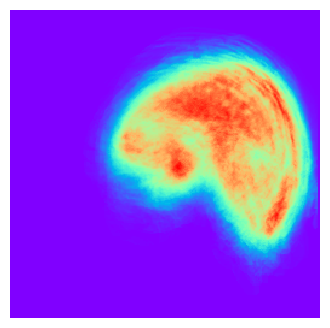

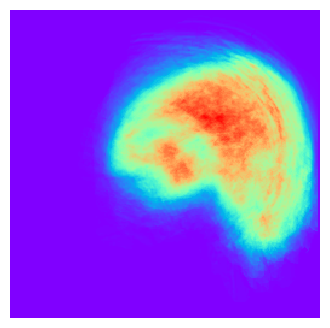

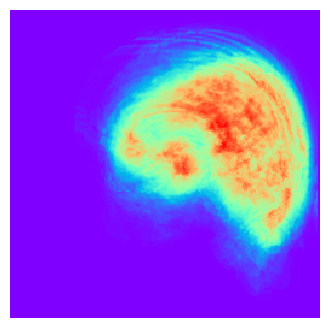

In [122]:
import seaborn as sns
import matplotlib.pyplot as plt
def fun_normalization(data):
    data = np.abs(data)
    _range = np.max(data) - np.min(data)
    return (data - np.min(data)) / _range

test_average = {'CN': np.zeros(X[0].shape), 'MCI': np.zeros(X[0].shape), 'AD': np.zeros(X[0].shape)}
for imp in list(test_average.keys()):
    i_list = np.where(Y_multi == imp)[0]
    for i in i_list:
        test_average[imp] += X[i]
    test_average[imp] /= len(i_list)

    plt.figure(figsize= (4,4))
    ax = plt.subplot(1,1,1)
    sns.heatmap(test_average[imp][:,:,78],cmap = "rainbow",cbar = False)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

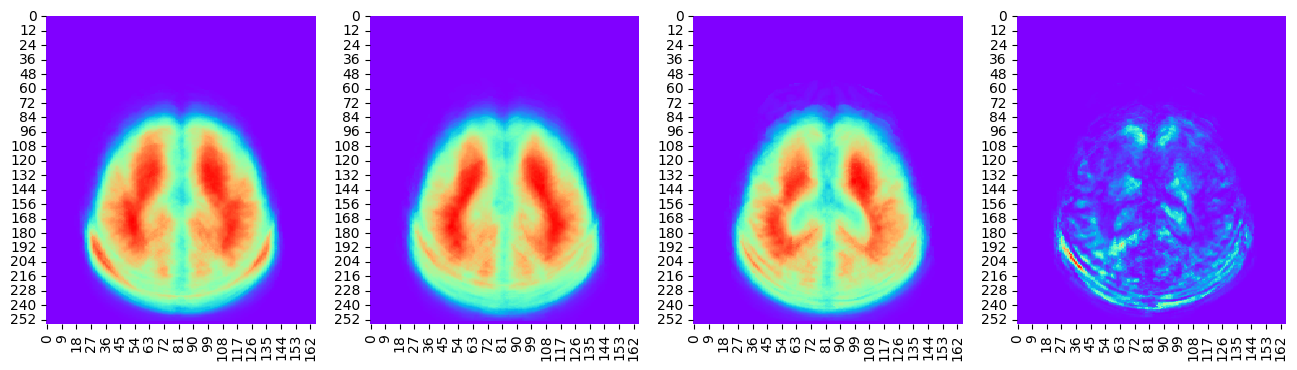

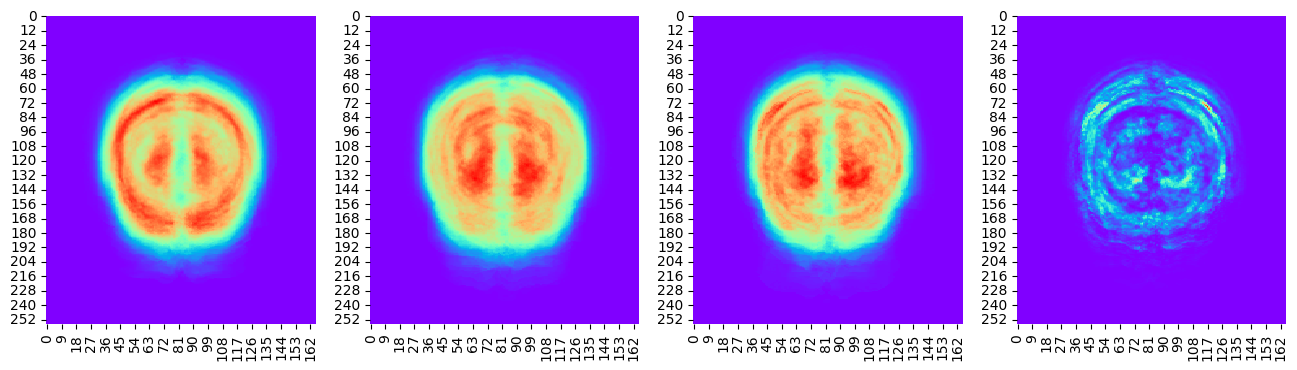

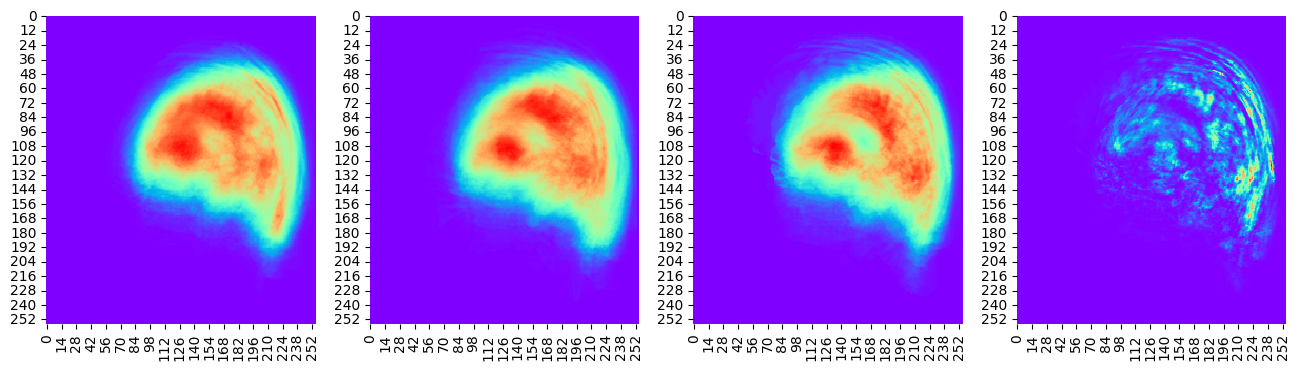

In [125]:
def extract(X, slice_number, order_number):
    idx = [slice(None)] * X.ndim
    idx[order_number] = slice_number
    return X[tuple(idx)]

average_variances = {}
max_var = []
for d in range(X[0].ndim):
    average_variances[d] = \
        [np.average(np.var([extract(test_average['CN'],i,d), extract(test_average['MCI'],i,d), extract(test_average['AD'],i,d)], axis=0)) for i in range(X[0].shape[d])]
    i_max = np.argmax(average_variances[d])
    max_var.append(i_max)
    
    plt.figure(figsize= (16,4))
    ax = plt.subplot(1,4,1)
    sns.heatmap(extract(test_average['CN'],i_max,d),cmap = "rainbow",cbar = False)
    ax = plt.subplot(1,4,2)
    sns.heatmap(extract(test_average['MCI'],i_max,d),cmap = "rainbow",cbar = False)
    ax = plt.subplot(1,4,3)
    sns.heatmap(extract(test_average['AD'],i_max,d),cmap = "rainbow",cbar = False)
    ax = plt.subplot(1,4,4)
    sns.heatmap(np.var([extract(test_average['CN'],i_max,d), extract(test_average['MCI'],i_max,d), extract(test_average['AD'],i_max,d)], axis=0),cmap = "rainbow",cbar = False)
    plt.show()

In [9]:
max_var = [107, 217, 67]

In [10]:
import numpy as np
from cskpd_new_update import *

def resize_image(image, new_height, new_width):
    # Mask of non-zeros
    # initiate as 96x96
    # image = cv2.bilateralFilter(image,9,75,75)
    image = np.array(image)
    original_height, original_width = image.shape
    mask = image != 0  # Use a >tolerance for a tolerance defining black border

    # Mask of non-zero rows and columns
    mask_row = mask.any(1)
    mask_col = mask.any(0)

    # First, last indices among the non-zero rows
    sr0, sr1 = mask_row.argmax(), len(mask_row) - mask_row[::-1].argmax()

    # First, last indices among the non-zero columns
    sc0, sc1 = mask_col.argmax(), len(mask_col) - mask_col[::-1].argmax()

    # Finally slice along the rows & cols with the start and stop indices to get
    # cropped image. Slicing helps for an efficient operation.
    cropped_image = image[sr0:sr1, sc0:sc1]

    # Original dimensions
    cropped_height, cropped_width = cropped_image.shape[:2]

    # Create an empty array for the resized image
    resized_image = np.zeros((new_height, new_width), dtype=np.float64)

    # Calculate the ratio of old dimensions to new dimensions
    row_ratio = cropped_height / new_height
    col_ratio = cropped_width / new_width

    # Map each pixel of the resized image to the nearest pixel of the original image
    for i in range(new_height):
        for j in range(new_width):
            # Find the nearest pixel in the original image
            original_i = int(i * row_ratio)
            original_j = int(j * col_ratio)

            # Assign the pixel value
            resized_image[i, j] = cropped_image[original_i, original_j]

    # Return the resized image and cropping boundaries
    return (resized_image, original_height, original_width, sr0, sr1, sc0, sc1)

def invert_resize_image(resized_image, original_height, original_width, sr0, sr1, sc0, sc1):
    # Calculate the height and width of the cropped image
    cropped_height = sr1 - sr0
    cropped_width = sc1 - sc0

    # Create an empty array for the cropped image
    cropped_image = np.zeros((cropped_height, cropped_width), dtype=np.float64)
    original_image = np.zeros((original_height, original_width), dtype=np.float64)

    # Calculate the ratio of new dimensions to old dimensions
    row_ratio = cropped_height / resized_image.shape[0]
    col_ratio = cropped_width / resized_image.shape[1]

    # Map each pixel of the cropped image to the nearest pixel of the resized image
    for i in range(cropped_height):
        for j in range(cropped_width):
            # Find the nearest pixel in the resized image
            resized_i = int(i / row_ratio)
            resized_j = int(j / col_ratio)

            # Assign the pixel value
            cropped_image[i, j] = resized_image[resized_i, resized_j]

    # Place the cropped image back into its original position
    original_image[sr0:sr1, sc0:sc1] = cropped_image

    return original_image

def extract_and_resize(X, slice, instance, size):
    slice_options = ['tra','cor','sag']
    assert slice in slice_options, f"slice: {slice}, provided is not an available option {slice_options}"
    if slice == 'tra': 
        X_ret = X[instance,:,:]
    if slice == 'cor':
        X_ret = X[:,instance,:]
    if slice == 'sag':
        X_ret = X[:,:,instance]
    return (resize_image(X_ret,*size), None)

def extract_slice(X, slice, number=None):
    return (X[slice], None)

In [11]:
K = convolution(resize_image, {'new_height': 96, 'new_width': 96}, invert_resize_image)
L = convolution(extract_and_resize, {'slice': 'tra', 'instance': max_var[0] , 'size': (96,96)}, extract_and_resize)
L = convolution(get_segment, {'segment': 0, 'size': (64,64,64)}, get_segment)

In [16]:
kernels = {
    'Identity': np.array([[0, 0, 0],
                              [0, 1, 0],
                              [0, 0, 0]]),
    '3x3 Rectangular Kernel': np.array([[1, 1, 1],
                            [1, 1, 1],
                            [1, 1, 1]]),
    '3x3 Ellipsoidal': np.array([[0, 1, 0],
                              [1, 1, 1],
                              [0, 1, 0]]),
    '5x5 Ellipsoidal': np.array([[0, 0, 1, 0, 0],
                            [0, 1, 1, 1, 0],
                            [1, 1, 1, 1, 1],
                            [0, 1, 1, 1, 0],
                            [0, 0, 1, 0, 0]]),
    'Horizontal Kernel': np.array([[-1, 0, 1],
                            [-1, 0, 1],
                            [-1, 0, 1]]),
}

In [12]:
kf = KFold(5,shuffle=True)
sample = np.array(range(len(Y)))
test_k = [idx[1] for idx in list(kf.split(sample))]
train_k = [np.setdiff1d(sample, k) for k in test_k]

In [130]:
folds = []
for i in range(5):
    p_list = [[24,24]]
    lam = [2**i for i in range(-2,0)]
    params = {
        'p': p_list,
        'lama': lam,
        'lamb': lam,
        'lamz': 0,
        'g': Logit(),
        # 'R': 1,
        'max_iter': 10,
        # 'K': K,
        'n_cores': 1
    }
    ensemble_model = EnsembleCSKPD()
    X_pick = [X[k] for k in train_k[i]]
    ensemble_model.fit(X_pick, Y[train_k[i]], model_parameters=[
        {'L': convolution(extract_and_resize, {'slice': 'tra', 'instance': max_var[0], 'size': (96,96)}, extract_and_resize)},
        {'L': convolution(extract_and_resize, {'slice': 'cor', 'instance': max_var[1], 'size': (96,96)}, extract_and_resize)},
        {'L': convolution(extract_and_resize, {'slice': 'sag', 'instance': max_var[2], 'size': (96,96)}, extract_and_resize)},
        ], common_parameters=params)
    folds.append(ensemble_model)

In [131]:
aucs = []
accs = []
for i, f in enumerate(folds):
    X_pick = [X[k] for k in test_k[i]]
    y_hat = f.predict(X_pick)
    aucs.append(auc(y_hat, Y[test_k[i]]))
    accs.append(np.average(np.round(y_hat,0) == Y[test_k[i]]))
auc_score = {}
acc_score = {}
y_hats = {}
for i, f in enumerate(folds):
    for j, e in enumerate(f.models):
        try:
            y_h = e.predict(X_pick)
            auc_score[(i,j)] = auc(y_h, Y[test_k[i]])
            # y_hats[(i,j)] = list(y_h)
            acc_score[(i,j)] = np.average(np.round(y_h,0) == Y[test_k[i]])
        except:
            pass
for k in range(len(folds[0].models)):
    score_auc = np.array([s for (i,j), s in auc_score.items() if j == k])
    score_acc = np.array([s for (i,j), s in acc_score.items() if j == k])
    print(f"Model {k}: AUC {np.round(np.average(score_auc),4)} ({np.round(np.std(score_auc),4)}), Accuracy {np.round(np.average(score_acc),4)} ({np.round(np.std(score_acc),4)}), Best AUC/Accuracy {np.max(score_auc)}/{np.max(score_acc)}")
print(f"Ensemble Model: AUC {np.round(np.average(aucs),4)} ({np.round(np.std(aucs),4)}), Accuracy {np.round(np.average(accs),4)} ({np.round(np.std(accs),4)}), Best AUC/Accuracy {np.max(aucs)}/{np.max(accs)}")

Model 0: AUC 0.4347 (0.0063), Accuracy 0.4099 (0.0225), Best AUC/Accuracy 0.44100391134289435/0.43243243243243246
Model 1: AUC 0.4455 (0.0367), Accuracy 0.4189 (0.0495), Best AUC/Accuracy 0.48213114754098363/0.46846846846846846
Model 2: AUC 0.4008 (0.0276), Accuracy 0.3694 (0.018), Best AUC/Accuracy 0.42834507042253517/0.38738738738738737
Ensemble Model: AUC 0.6055 (0.0307), Accuracy 0.6255 (0.0225), Best AUC/Accuracy 0.6529032258064518/0.6607142857142857


In [23]:
def print_results(folds, X, Y, test_k):
    aucs = []
    accs = []
    for i, f in enumerate(folds):
        X_pick = [X[k] for k in test_k[i]]
        y_hat = f.predict(X_pick)
        aucs.append(auc(y_hat, Y[test_k[i]]))
        accs.append(np.average(np.round(y_hat,0) == Y[test_k[i]]))
    auc_score = {}
    acc_score = {}
    y_hats = {}
    for i, f in enumerate(folds):
        for j, e in enumerate(f.models):
            try:
                y_h = e.predict(X_pick)
                auc_score[(i,j)] = auc(y_h, Y[test_k[i]])
                # y_hats[(i,j)] = list(y_h)
                acc_score[(i,j)] = np.average(np.round(y_h,0) == Y[test_k[i]])
            except:
                pass
    for k in range(len(folds[0].models)):
        score_auc = np.array([s for (i,j), s in auc_score.items() if j == k])
        score_acc = np.array([s for (i,j), s in acc_score.items() if j == k])
        print(f"Model {k}: AUC {np.round(np.average(score_auc),4)} ({np.round(np.std(score_auc),4)}), Accuracy {np.round(np.average(score_acc),4)} ({np.round(np.std(score_acc),4)}), Best AUC/Accuracy {np.max(score_auc)}/{np.max(score_acc)}")
    print(f"Ensemble Model: AUC {np.round(np.average(aucs),4)} ({np.round(np.std(aucs),4)}), Accuracy {np.round(np.average(accs),4)} ({np.round(np.std(accs),4)}), Best AUC/Accuracy {np.max(aucs)}/{np.max(accs)}")
    return aucs, accs

In [133]:
folds_y0 = []
folds_y1 = []
mp = [
        {'L': convolution(extract_and_resize, {'slice': 'tra', 'instance': max_var[0], 'size': (96,96)}, extract_and_resize)},
        {'L': convolution(extract_and_resize, {'slice': 'cor', 'instance': max_var[1], 'size': (96,96)}, extract_and_resize)},
        {'L': convolution(extract_and_resize, {'slice': 'sag', 'instance': max_var[2], 'size': (96,96)}, extract_and_resize)},
    ]
for i in range(5):
    X_pick = [X[k] for k in train_k[i]]
    ensemble_model_y0 = EnsembleCSKPD()
    ensemble_model_y0.fit(X_pick, Y[train_k[i]], model_parameters=mp, common_parameters=params)
    folds_y0.append(ensemble_model_y0)
    ensemble_model_y1 = EnsembleCSKPD()
    ensemble_model_y1.fit(X_pick, Y[train_k[i]], model_parameters=mp, common_parameters=params)
    folds_y1.append(ensemble_model_y1)

c:\Users\joshu\OneDrive\Documents\Dissertation\CSKPD\cskpd_new_update.py:44: RuntimeWarning: invalid value encountered in scalar divide
  stability = np.var(B)/(norm(B, 2)**2)
c:\Users\joshu\OneDrive\Documents\Dissertation\CSKPD\cskpd_new_update.py:54: RuntimeWarning: divide by zero encountered in scalar divide
  (np.linalg.norm(score['B'], 'fro') - norms[1])/norms[1],
c:\Users\joshu\OneDrive\Documents\Dissertation\CSKPD\cskpd_new_update.py:44: RuntimeWarning: invalid value encountered in scalar divide
  stability = np.var(B)/(norm(B, 2)**2)
c:\Users\joshu\OneDrive\Documents\Dissertation\CSKPD\cskpd_new_update.py:54: RuntimeWarning: invalid value encountered in scalar divide
  (np.linalg.norm(score['B'], 'fro') - norms[1])/norms[1],
c:\Users\joshu\OneDrive\Documents\Dissertation\CSKPD\cskpd_new_update.py:44: RuntimeWarning: invalid value encountered in scalar divide
  stability = np.var(B)/(norm(B, 2)**2)
c:\Users\joshu\OneDrive\Documents\Dissertation\CSKPD\cskpd_new_update.py:54: Runt

In [135]:
print_results(folds_y0, X, np.array(Y0), test_k)
print_results(folds_y1, X, np.array(Y1), test_k)

c:\Users\joshu\miniconda3\envs\antsenv\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Model 0: AUC 0.4747 (0.0322), Accuracy 0.4414 (0.045), Best AUC/Accuracy 0.5068627450980392/0.4864864864864865
Model 1: AUC nan (nan), Accuracy 0.3468 (0.0135), Best AUC/Accuracy nan/0.36036036036036034
Model 2: AUC 0.4063 (0.022), Accuracy 0.3739 (0.0135), Best AUC/Accuracy 0.42834507042253517/0.38738738738738737
Ensemble Model: AUC 0.5645 (0.0374), Accuracy 0.5915 (0.0288), Best AUC/Accuracy 0.6156716417910448/0.6396396396396397


c:\Users\joshu\miniconda3\envs\antsenv\Lib\site-packages\sklearn\metrics\_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Model 0: AUC 0.536 (0.0474), Accuracy 0.5856 (0.009), Best AUC/Accuracy 0.5833333333333334/0.5945945945945946
Model 1: AUC nan (nan), Accuracy 0.7523 (0.0045), Best AUC/Accuracy nan/0.7567567567567568
Model 2: AUC 0.4925 (0.0057), Accuracy 0.5541 (0.0135), Best AUC/Accuracy 0.4982394366197183/0.5675675675675675
Ensemble Model: AUC 0.5087 (0.034), Accuracy 0.4607 (0.0461), Best AUC/Accuracy 0.5613890717577353/0.5315315315315315


([0.5208333333333333,
  0.48863636363636365,
  0.4592923394022672,
  0.5613890717577353,
  0.5132293080054274],
 [0.48214285714285715,
  0.4375,
  0.39285714285714285,
  0.5315315315315315,
  0.4594594594594595])

With segments

In [20]:
Y_multi = np.array([[0,0] if y == 'CN' else [0,1] if y == 'MCI' else [1,1] for y in Y])
Y0 = np.array([y for y, _ in Y_multi])
Y1 = np.array([y for _, y in Y_multi])    

In [21]:
p_list = [[16,16,16]]
lam = [2**i for i in range(-2,0)]
params = {
    'p': p_list,
    'lama': lam,
    'lamb': 0,
    'lamz': 0,
    'g': Logit(),
    # 'R': 1,
    'max_iter': 10,
    # 'K': K,
    'n_cores': 1
}
folds_y0 = []
folds_y1 = []
mp = [
        {'L': convolution(get_segment, {'segment': 0, 'size': (64,64,64)}, get_segment)},
        {'L': convolution(get_segment, {'segment': 1, 'size': (64,64,64)}, get_segment)},
    ]
for i in range(5):
    X_pick = [X[k] for k in train_k[i]]
    ensemble_model_y0 = EnsembleCSKPD()
    ensemble_model_y0.fit(X_pick, Y0[train_k[i]], model_parameters=mp, common_parameters=params)
    folds_y0.append(ensemble_model_y0)
    ensemble_model_y1 = EnsembleCSKPD()
    ensemble_model_y1.fit(X_pick, Y1[train_k[i]], model_parameters=mp, common_parameters=params)
    folds_y1.append(ensemble_model_y1)

In [24]:
print_results(folds_y0, X, np.array(Y0), test_k)
print_results(folds_y1, X, np.array(Y1), test_k)

Model 0: AUC 0.4292 (0.0942), Accuracy 0.3648 (0.0941), Best AUC/Accuracy 0.5398550724637682/0.49056603773584906
Model 1: AUC 0.3824 (0.0379), Accuracy 0.3019 (0.0308), Best AUC/Accuracy 0.4255050505050505/0.33962264150943394
Ensemble Model: AUC 0.5875 (0.0865), Accuracy 0.6331 (0.0773), Best AUC/Accuracy 0.7191091954022988/0.7358490566037735
Model 0: AUC 0.4783 (0.0167), Accuracy 0.4654 (0.0235), Best AUC/Accuracy 0.49857142857142855/0.49056603773584906
Model 1: AUC 0.4306 (0.0976), Accuracy 0.4214 (0.0876), Best AUC/Accuracy 0.5121082621082621/0.5094339622641509
Ensemble Model: AUC 0.6343 (0.0293), Accuracy 0.6516 (0.017), Best AUC/Accuracy 0.6677631578947368/0.6851851851851852


([0.6677631578947368,
  0.6082706766917294,
  0.6564285714285714,
  0.5914634146341464,
  0.6476190476190476],
 [0.6851851851851852,
  0.6481481481481481,
  0.6415094339622641,
  0.6415094339622641,
  0.6415094339622641])

In [13]:
def get_segment(X_description, segment, size=None):
    img = ants.image_read(f'data/adni_segments/segments_1plus2/{X_description}_seg_{segment}.nii')
    if size is not None:
        img = ants.resample_image(img, resample_params=size, use_voxels=True, interp_type=1)
    return (img.numpy(), segment, size)

In [16]:
L = convolution(get_segment, {'segment': 0, 'size': (64,62,64)}, get_segment)
L.convolve(X[0]).shape

(64, 62, 64)